# 07 · Build a wheel and run it outside the repository

Turn the raster workflow into an installed command-line tool, then verify its result from a fresh environment. This notebook needs uv and internet for installation.

[Notebook index](README.md) · [Companion article](../docs/articles/shipping-geoai.md) · [Data sources and licences](../docs/DATA_SOURCES.md)

Run every cell from top to bottom in the locked Python 3.12 environment. The first run downloads the required public data pack and checks its SHA-256. Generated artifacts remain in the ignored `outputs/` directory.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython import get_ipython
from IPython.display import display

from geoai_portfolio.io import ensure_data, root, workspace

get_ipython().run_line_magic("matplotlib", "inline")
plt.rcParams.update(
    {
        "figure.dpi": 110,
        "figure.figsize": (10, 4),
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "bold",
        "axes.labelsize": 9,
        "axes.titlesize": 11,
        "font.size": 10,
        "savefig.bbox": "tight",
    }
)
pd.set_option("display.precision", 4)

In [2]:
from geoai_portfolio.shipping import verify_wheel

data = ensure_data("satellite")
out = workspace("07-shipping")
checkout = root()
display(
    pd.DataFrame(
        {
            "interface": ["Python", "CLI", "Container"],
            "entry": [
                "geoai_portfolio.rasters.windowed_ndvi",
                "geoai-portfolio ndvi",
                "Dockerfile; Ubuntu CI smoke check",
            ],
        }
    )
)

,interface,entry
0,Python,geoai_portfolio.rasters.windowed_ndvi
1,CLI,geoai-portfolio ndvi
2,Container,Dockerfile; Ubuntu CI smoke check


## Build, install, and execute a concrete artifact

The verification function builds the wheel using the pinned build backend, exports the
frozen base dependency lock, creates a separate virtual environment outside the checkout,
and installs the wheel plus those dependencies. It then invokes the installed CLI with
explicit input paths and a fresh working directory. The isolated interpreter does not
use a source-tree `PYTHONPATH`. Installation can take several minutes on an empty cache.

In [3]:
result = verify_wheel(checkout, data, out)
display(pd.DataFrame([result]))
assert result["array_matches_reference"]

,wheel,wheel_sha256,environment,array_matches_reference,windows,valid_pixels,window_size,largest_input_pixels
0,geoai_portfolio_examples-2.0.0-py3-none-any.whl,ebe7de421d30f1585c64d2e8bc473c3f822d83fc6a1c39...,"separate venv, locked base dependencies, outsi...",True,16,261429,128,16384


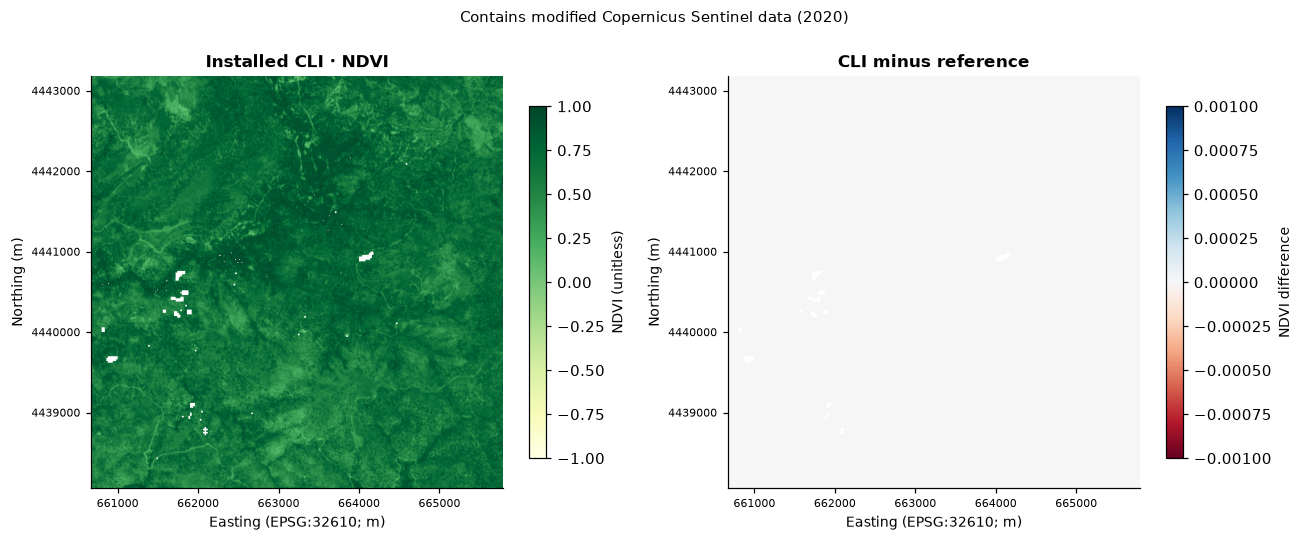

In [4]:
import rasterio

from geoai_portfolio.rasters import map_array, scene_ndvi

with rasterio.open(out / "installed-ndvi.tif") as source:
    saved = source.read(1, masked=True)
    reference = scene_ndvi(data / "before.tif", data / "before-scl.tif")
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    image = map_array(axes[0], saved, source, "Installed CLI · NDVI", "YlGn", -1, 1)
    fig.colorbar(image, ax=axes[0], label="NDVI (unitless)", shrink=0.75)
    difference = saved - reference
    image = map_array(axes[1], difference, source, "CLI minus reference", "RdBu", -0.001, 0.001)
    fig.colorbar(image, ax=axes[1], label="NDVI difference", shrink=0.75)
fig.suptitle("Contains modified Copernicus Sentinel data (2020)", fontsize=10)
plt.tight_layout()
plt.show()

## Container boundary

The repository's [Dockerfile](../Dockerfile) uses the same package and frozen dependency
lock. The [validation workflow](../.github/workflows/validate.yml) builds it on Ubuntu
and executes the CLI against a tiny public fixture with network access disabled during
inference. Local Run All does not require Docker. Consult the workflow result for
evidence of the container check; the notebook's wheel result alone does not establish it.

The output checksum identifies this concrete artifact, while array equality verifies
the scientific result. Wheel bytes can differ with build metadata even when predictions
agree. Neither wheel installation nor a container makes unspecified data conventions safe.